SVM is sensitive to feature scaling, 
so we begin with it

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [2]:
TRAIN_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "train_windows.parquet"
)

TEST_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "test_windows.parquet"
)

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7335
Testing rows: 1577


In [3]:
columns_not_used_for_model = [
    "participant_id",
    "recording_id",
    "window_number",
    "start_time_ms",
    "end_time_ms",
    "fog"
]

feature_columns = [
    column
    for column in train_df.columns
    if column not in columns_not_used_for_model
]

X_train = train_df[feature_columns]
y_train = train_df["fog"]

X_test = test_df[feature_columns]
y_test = test_df["fog"]

print("Number of features:", len(feature_columns))

Number of features: 45


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
predictions = svm_model.predict(X_test_scaled)

In [8]:
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    zero_division=0
)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

Accuracy: 0.869
Precision: 0.527
Recall: 0.658
F1-score: 0.585


In [9]:
prediction_report = test_df[
    [
        "participant_id",
        "recording_id",
        "window_number",
        "start_time_ms",
        "end_time_ms",
        "fog"
    ]
].copy()

prediction_report["predicted_fog"] = predictions

prediction_report["start_time_seconds"] = (
    prediction_report["start_time_ms"] / 1000
)

prediction_report["end_time_seconds"] = (
    prediction_report["end_time_ms"] / 1000
)

prediction_report.head()

,participant_id,recording_id,window_number,start_time_ms,end_time_ms,fog,predicted_fog,start_time_seconds,end_time_seconds
0,S02,R01,0,670000,671984,0,0,670.0,671.984
1,S02,R01,1,672000,673984,0,0,672.0,673.984
2,S02,R01,2,674000,675984,0,0,674.0,675.984
3,S02,R01,3,676000,677984,0,0,676.0,677.984
4,S02,R01,4,678000,679984,0,0,678.0,679.984


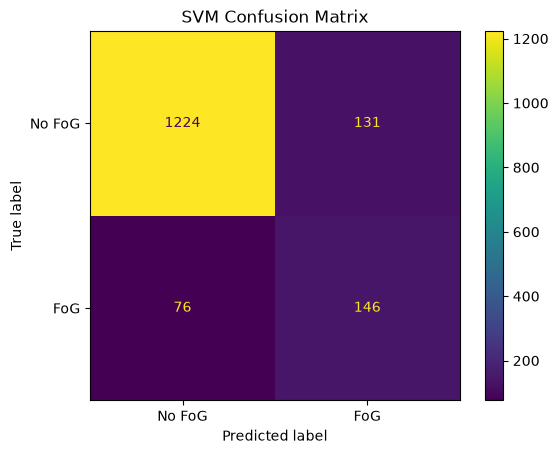

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["No FoG", "FoG"]
)

plt.title("SVM Confusion Matrix")
plt.show()